# Homework 4


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score




In [2]:
# import function
def refresh_data():
    df = pd.read_csv("AER_credit_card_data.csv")

    
    # change card mapping to 0
    df['card'] = (df.card == 'yes').astype(int)

    return df

In [3]:
columns = ["reports", "age", "income", "share", "expenditure", "dependents", "months", "majorcards", "active", "owner", "selfemp"]

In [4]:
# split data function
def split_data(dataframe):
    df = dataframe.copy()
    df[columns+['card']]
    # split data
    df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
    df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
    
    # reset index
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    # y
    y_train = df_train.card.values
    y_val = df_val.card.values
    y_test = df_test.card.values
    
    # remove from dfs
    del df_train['card']
    del df_val['card']
    del df_test['card']
    
    # return a dict
    data = {
        'df_train': df_train,
        'df_val': df_val,
        'df_test': df_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test
    }
    
    return data

In [5]:
def prepare_X(df_train, df_val, categorical, numerical):
    dv = DictVectorizer(sparse=False)
    
    dict_train = df_train[categorical+numerical].to_dict(orient='records')
    dv.fit(dict_train)
    X_train = dv.transform(dict_train)

    #val
    dict_val = df_val[categorical+numerical].to_dict(orient='records')
    X_val = dv.transform(dict_val)
    
    return X_train, X_val

In [6]:
df = refresh_data()

In [7]:
df.shape

(1319, 12)

In [8]:
df.columns

Index(['card', 'reports', 'age', 'income', 'share', 'expenditure', 'owner',
       'selfemp', 'dependents', 'months', 'majorcards', 'active'],
      dtype='object')

In [9]:
df.head()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
0,1,0,37.66667,4.5200,0.033270,124.983300,yes,no,3,54,1,12
1,1,0,33.25000,2.4200,0.005217,9.854167,no,no,3,34,1,13
2,1,0,33.66667,4.5000,0.004156,15.000000,yes,no,4,58,1,5
3,1,0,30.50000,2.5400,0.065214,137.869200,no,no,0,25,1,7
4,1,0,32.16667,9.7867,0.067051,546.503300,yes,no,2,64,1,5


## Question 1


In [10]:
df = refresh_data()
data = split_data(df)

In [11]:
categorical = ['owner', 'selfemp']

In [12]:
numerical = ['reports', 'age', 'income', 'share', 'expenditure',
             'dependents', 'months', 'majorcards', 'active']

In [13]:
scores = []
for n in numerical:
    score = roc_auc_score(data['y_train'], data['df_train'][n])
    if score < 0.5:
        score = roc_auc_score(data['y_train'], -data['df_train'][n])
    scores.append((n, score))
    
scores.sort(key = lambda r: r[1])
scores

[('age', 0.5240020979407055),
 ('months', 0.5294217780967629),
 ('dependents', 0.5327757227773791),
 ('majorcards', 0.5343859842838476),
 ('income', 0.5908049467233478),
 ('active', 0.6043173411362006),
 ('reports', 0.7166629860689376),
 ('share', 0.989183643423692),
 ('expenditure', 0.991042345276873)]

Q1. D. Share

## Question 2


In [14]:
columns

['reports',
 'age',
 'income',
 'share',
 'expenditure',
 'dependents',
 'months',
 'majorcards',
 'active',
 'owner',
 'selfemp']

In [15]:
categorical = ['owner', 'selfemp']

In [16]:
numerical = ['reports',
 'age',
 'income',
 'share',
 'expenditure',
 'dependents',
 'months',
 'majorcards',
 'active']

In [17]:
df = refresh_data()
data = split_data(df)

In [18]:
X_train, X_val = prepare_X(data['df_train'],data['df_val'], categorical, numerical)

In [19]:
model = LogisticRegression(solver="liblinear", C=1.0, max_iter=1000)

In [20]:
model.fit(X_train, data['y_train'])

LogisticRegression(max_iter=1000, solver='liblinear')

In [21]:
y_pred = model.predict_proba(X_val)[:, 1]

In [22]:
roc_auc_score(data['y_val'], y_pred)

0.995171242063847

Q2. D. 0.995

## Question 3


In [23]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (data['y_val'] == 1)
    actual_negative = (data['y_val'] == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
    
    tp = (predict_positive & actual_positive).sum() # number of true positive
    tn = (predict_negative & actual_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))


In [24]:
precs = list()
recalls = list()
for s in scores:
    prec = s[1]/ (s[1]+s[2])
    recall = s[1] / (s[3] +s[1])
    precs.append(prec)
    recalls.append(recall)

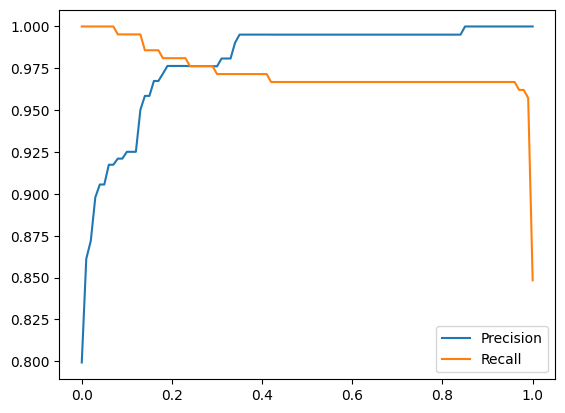

In [25]:
plt.plot(thresholds, precs, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.legend()
plt.show()

Q3. B. 0.3

## Question 4


In [26]:
# computing for f1
max_f1 = (None,float('-inf'))
f1s = list()
for t, p, r in zip(thresholds, precs, recalls):
    f1 = 2 * p * r / (p+r)
    
    if f1 > max_f1[1]:
        max_f1 = (t, f1)
    f1s.append(f1)

In [27]:
max_f1

(0.35000000000000003, 0.9832134292565947)

Q4. B. 0.4

## Question 5


In [28]:
def train(df, y, C=1.0):
    dicts = df[categorical+numerical].to_dict(orient='records')
    
    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)
    
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y)
    
    return dv, model

In [29]:
def predict(df, dv, model):
    dicts = df[categorical+numerical].to_dict(orient='records')
    
    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [30]:
df = refresh_data()
data = split_data(df)

In [31]:
df_full_train = pd.concat([data['df_train'], data['df_val']]).reset_index(drop=True)

In [32]:
y_full_train = np.concatenate([data['y_train'], data['y_val']])

In [33]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
scores = list()
c = 0
for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]
    
    y_train = y_full_train[train_idx]
    y_val = y_full_train[val_idx]
    
    dv, model = train(df_train, y_train, C=1)
    y_pred = predict(df_val, dv, model)
    
    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

In [34]:
np.std(scores)

0.005280277859810096

Q5. A. 0.003

# Question 6

In [35]:
df = refresh_data()
data = split_data(df)

In [36]:
df_full_train = pd.concat([data['df_train'], data['df_val']]).reset_index(drop=True)
y_full_train = np.concatenate([data['y_train'], data['y_val']])


In [37]:
results = list()
for c in [0.01, 0.1, 1, 10]:
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
    scores = list()
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
        
        y_train = y_full_train[train_idx]
        y_val = y_full_train[val_idx]
        
        dv, model = train(df_train, y_train, C=c)
        y_pred = predict(df_val, dv, model)
        
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    results.append((c, np.mean(scores), np.std(scores)))
    
results

[(0.01, 0.9912552283173577, 0.005461790119371774),
 (0.1, 0.9946231535564714, 0.005439573341144853),
 (1, 0.9953585545134281, 0.005280277859810096),
 (10, 0.9957601609391311, 0.004624645455641291)]

In [38]:
results.sort(key = lambda r: r[1])

In [39]:
results

[(0.01, 0.9912552283173577, 0.005461790119371774),
 (0.1, 0.9946231535564714, 0.005439573341144853),
 (1, 0.9953585545134281, 0.005280277859810096),
 (10, 0.9957601609391311, 0.004624645455641291)]